In [ ]:
import pandas as pd

fake = pd.read_csv("/content/Fake.csv.zip")
real = pd.read_csv("/content/True.csv.zip")

print(fake.shape)
print(real.shape)

(23481, 4)
(21417, 4)


In [ ]:
import pandas as pd

fake = pd.read_csv("/content/Fake.csv.zip")

real = pd.read_csv("/content/True.csv.zip")
print(fake)
print(real)

                                                   title  \
0       Donald Trump Sends Out Embarrassing New Year’...   
1       Drunk Bragging Trump Staffer Started Russian ...   
2       Sheriff David Clarke Becomes An Internet Joke...   
3       Trump Is So Obsessed He Even Has Obama’s Name...   
4       Pope Francis Just Called Out Donald Trump Dur...   
...                                                  ...   
23476  McPain: John McCain Furious That Iran Treated ...   
23477  JUSTICE? Yahoo Settles E-mail Privacy Class-ac...   
23478  Sunnistan: US and Allied ‘Safe Zone’ Plan to T...   
23479  How to Blow $700 Million: Al Jazeera America F...   
23480  10 U.S. Navy Sailors Held by Iranian Military ...   

                                                    text      subject  \
0      Donald Trump just couldn t wish all Americans ...         News   
1      House Intelligence Committee Chairman Devin Nu...         News   
2      On Friday, it was revealed that former Milwauk...    

In [ ]:
fake["label"] = 0   # 0 = Fake
real["label"] = 1   # 1 = Real

In [ ]:
data = pd.concat([fake, real], axis=0)
data = data.sample(frac=1).reset_index(drop=True)  # shuffle

In [ ]:
data["content"] = data["title"] + " " + data["text"]

In [ ]:
print(data.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'content'], dtype='object')


In [ ]:
X = data["content"]
y = data["label"]

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

X = X.apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9865256124721603
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4737
           1       0.98      0.99      0.99      4243

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [ ]:
pip install shap

In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)
X_test_df = pd.DataFrame(X_test_tfidf.toarray(), columns=feature_names)

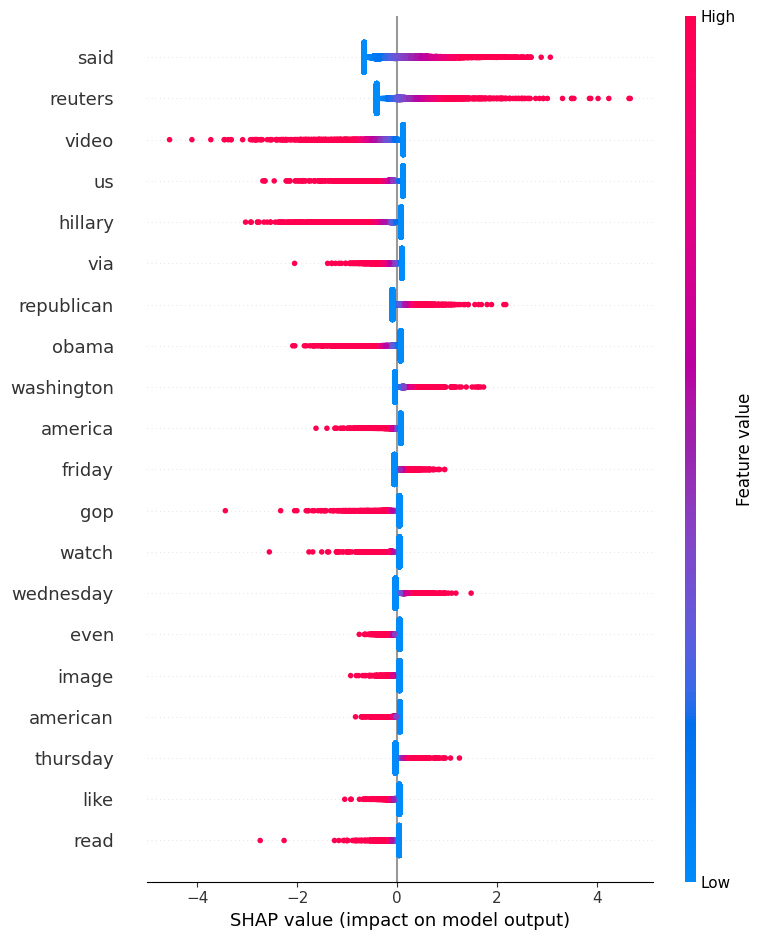

In [ ]:
import shap

explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, nb_pred))

Naive Bayes Accuracy: 0.9287305122494433
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      4737
           1       0.93      0.92      0.92      4243

    accuracy                           0.93      8980
   macro avg       0.93      0.93      0.93      8980
weighted avg       0.93      0.93      0.93      8980

Confusion Matrix:
 [[4439  298]
 [ 342 3901]]


In [ ]:
nb_model.feature_log_prob_

array([[-11.66371377,  -9.99538613,  -9.88788728, ...,  -9.61276713,
        -11.4773254 , -12.000718  ],
       [ -8.76042611,  -9.37012189,  -9.49488139, ...,  -9.36220347,
         -8.69872501,  -8.33875653]])

In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
import numpy as np

fake_log_probs = nb_model.feature_log_prob_[0]
real_log_probs = nb_model.feature_log_prob_[1]

# Difference score
word_difference = fake_log_probs - real_log_probs

In [ ]:
top_fake_indices = np.argsort(word_difference)[-20:]

top_fake_words = [feature_names[i] for i in top_fake_indices]

print("Top Fake Indicating Words:")
print(top_fake_words)

Top Fake Indicating Words:
['cop', 'image', 'ck', 'henningsen', 'wow', 'flickr', 'bundy', 'hannity', 'com', 'screenshot', 'cops', 'wire', 'hilarious', 'gop', 'js', 'acr', 'featured', 'boiler', 'getty', 'pic']


In [ ]:
top_real_indices = np.argsort(word_difference)[:20]

top_real_words = [feature_names[i] for i in top_real_indices]

print("Top Real Indicating Words:")
print(top_real_words)

Top Real Indicating Words:
['myanmar', 'rohingya', 'reuters', 'catalan', 'hariri', 'catalonia', 'mugabe', 'puigdemont', 'rakhine', 'zuma', 'ankara', 'ria', 'spd', 'graft', 'mnangagwa', 'odinga', 'kirkuk', 'rajoy', 'kurdish', 'beijing']


In [ ]:
sample_index = 10

sample_text = X_test.iloc[sample_index]
sample_vector = X_test_tfidf[sample_index]

prediction = nb_model.predict(sample_vector)

print("Prediction:", prediction)
print("Text:\n", sample_text)

Prediction: [0]
Text:
 guatemalan president keep straight face mocks donald trump video donald trump called yet another foreign leader ridiculous plan build great wall murica facebook live interview new york times en espa ol guatemalan president jimmy morales former television comedian openly mocked republican wall trump rose top republican primary race promising supporters going erect huge wall keep latino immigrants country although said going force mexico hahaha pay monstrosity also promised going built really inexpensively order going need cheap labor rails speeches president morales offered gentleman wants build wall offer cheap labor high quality labor gladly build tell us dimensions know president could hardly keep straight face offered help gentleman quickly turned serious started discussing real immigration policy reporter saying believe although reason involve u migratory policy believe necessary think migratory reform many people irregular manner regularized said morales add

In [ ]:
non_zero_indices = sample_vector.nonzero()[1]

for i in non_zero_indices[:20]:
    print(feature_names[i],
          "Fake Score:", fake_log_probs[i],
          "Real Score:", real_log_probs[i])

absolutely Fake Score: -7.703555253991103 Real Score: -9.134144898304996
added Fake Score: -7.864939457619726 Real Score: -7.2346203369724496
also Fake Score: -6.563896115590559 Real Score: -6.392156014973195
although Fake Score: -8.322045799561298 Real Score: -7.888409550885245
america Fake Score: -6.311921472905307 Real Score: -7.874067627791732
another Fake Score: -6.957376032401683 Real Score: -7.4769348145830135
back Fake Score: -6.667165256401618 Real Score: -7.219500680858183
base Fake Score: -8.316689546591585 Real Score: -8.146651726711934
believe Fake Score: -7.170230707439463 Real Score: -7.988202378866658
benefit Fake Score: -8.838122378160932 Real Score: -8.737448238074546
blame Fake Score: -8.019856086504323 Real Score: -9.06200032850732
blue Fake Score: -8.484928133337313 Real Score: -9.136816101130476
build Fake Score: -8.351266005164149 Real Score: -8.017748289795483
built Fake Score: -8.721848913526848 Real Score: -8.708174232851372
called Fake Score: -7.0425386953030

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, svm_pred))

SVM Accuracy: 0.9951002227171493
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4737
           1       1.00      0.99      0.99      4243

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Confusion Matrix:
 [[4717   20]
 [  24 4219]]


In [ ]:
svm_model.coef_

array([[ 0.05283915, -0.18584372,  0.09002165, ..., -0.22638076,
         0.29920184,  0.54940775]])

In [ ]:
feature_names = vectorizer.get_feature_names_out()

In [ ]:
import numpy as np

svm_weights = svm_model.coef_[0]

In [ ]:
top_fake_indices = np.argsort(svm_weights)[:20]

top_fake_words = [feature_names[i] for i in top_fake_indices]

print("Top Fake Words (SVM):")
print(top_fake_words)

Top Fake Words (SVM):
['via', 'read', 'video', 'breaking', 'gop', 'us', 'featured', 'watch', 'image', 'getty', 'hillary', 'mr', 'com', 'wire', 'rep', 'sen', 'pic', 'entire', 'images', 'breitbart']


In [ ]:
top_real_indices = np.argsort(svm_weights)[-20:]

top_real_words = [feature_names[i] for i in top_real_indices]

print("Top Real Words (SVM):")
print(top_real_words)

Top Real Words (SVM):
['barack', 'york', 'democratic', 'rival', 'showed', 'comment', 'est', 'tuesday', 'saying', 'km', 'edt', 'thursday', 'friday', 'republican', 'wednesday', 'factbox', 'nov', 'washington', 'said', 'reuters']


In [ ]:
for i in top_fake_indices:
    print(feature_names[i], svm_weights[i])

via -8.217474997975897
read -5.360166936873592
video -4.033120513894739
breaking -3.5922690600450604
gop -3.175326661791527
us -3.1199632083686115
featured -2.857976487251216
watch -2.7810324184070176
image -2.7763455027604973
getty -2.7304725203944304
hillary -2.5844703703887526
mr -2.458272712962324
com -2.3508210627825163
wire -2.3039799006419193
rep -2.3009043131998994
sen -2.2431291411811545
pic -2.105360464008457
entire -2.0606785579848386
images -1.9437958684651568
breitbart -1.8846804697851753
